```markdown
SCT211-0848/2018
Jany Muong
```
# ICS 2405: Knowledge-Based Systems
### NSE Stock Price Prediction - Regression Models:


> ##### CONTEXT:  
 > Predict next-day stock prices using regression models on Nairobi NSE data (2010-2012).

**DATASET**: Nairobi Securities Exchange All Stocks Prices (2010-2012)
- **Records**: ~45,000 daily trading records
- **Stocks**: 70+ unique stocks
- **Features**: 19 engineered features (lag prices, momentum, volatility, volume)
- **Target**: Next-day stock price

**Models**:
1. Baseline models (Mean, Median, Last Value)
2. Linear Regression (with Ridge and Lasso regularization)
3. Decision Tree Regressor
4. K-Nearest Neighbors (k=5)
5. LinearSVR (fast linear Support Vector Regression)
6. Random Forest Regressor (ensemble)

**Metrics**:
```sh
- MSE, RMSE, MAE (error magnitude)
- R² Score (variance explained)
- MAPE (percentage error)
- Error plots (predicted vs actual)
- Residual plots (systematic error detection)
```
---

1. Setup - Import Libraries + Config:
============================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools as it
%matplotlib inline

# models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, NuSVR, LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

# preprocessing + pipeline
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn import pipeline

# metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
    make_scorer
)

import warnings
warnings.filterwarnings('ignore')

# settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# for reproducibility
np.random.seed(42)

In [2]:
# helper functions for regression evaluation 
# from mlwpy reference text

def rms_error(actual, predicted):
    '''root-mean-squared-error function'''
    mse = mean_squared_error(actual, predicted)
    return np.sqrt(mse)

def neg_rmse_score(actual, predicted):
    '''RMSE based score function (negative for sklearn compatibility)'''
    return -rms_error(actual, predicted)

def regression_errors(figsize, predicted, actual, errors='all'):
    '''plot actual vs predicted from both perspectives'''
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)
    df = pd.DataFrame({'actual': actual, 'predicted': predicted})
 
    for ax, (x, y) in zip(axes, it.permutations(['actual', 'predicted'])):
        # plot data points and perfect prediction line
        ax.plot(df[x], df[y], '.', label='data', alpha=0.6)
        ax.plot(df['actual'], df['actual'], '-', label='perfect', color='red', linewidth=2)
        ax.legend()
        ax.set_xlabel(f'{x.capitalize()} Value')
        ax.set_ylabel(f'{y.capitalize()} Value')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

    axes[1].yaxis.tick_right()
    axes[1].yaxis.set_label_position("right")
    
    # show error bars
    if errors == 'all':
        errors = range(min(50, len(df)))  # limit to 50 for clarity
    
    if errors:
        acts = df.actual.iloc[errors]
        preds = df.predicted.iloc[errors]
        axes[0].vlines(acts, preds, acts, 'r', alpha=0.3)
        axes[1].hlines(acts, preds, acts, 'r', alpha=0.3)
    
    return fig, axes

def regression_residuals(ax, predicted, actual, show_errors=None, right=False):
    '''Plot residuals vs predicted values'''
    df = pd.DataFrame({'actual': actual, 'predicted': predicted})
    df['residual'] = df.actual - df.predicted
    
    ax.plot(df.predicted, df.residual, '.', alpha=0.6)
    ax.axhline(y=0, color='red', linestyle='-', linewidth=2)
    
    if right:
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

    ax.set_xlabel('Predicted Value')
    ax.set_ylabel('Residual (Actual - Predicted)')
    ax.grid(True, alpha=0.3)

    if show_errors == 'all':
        show_errors = range(min(50, len(df)))

    if show_errors:
        preds = df.predicted.iloc[show_errors]
        resids = df.residual.iloc[show_errors]
        ax.vlines(preds, 0, resids, 'r', alpha=0.3)

print("REGRESSION FUNCTIONS")

REGRESSION FUNCTIONS


2. Load Dataset:
================

> This is a segment meant to examine 6 years worth of NSE data (2007-2012) - the structure of it.

In [3]:
import os
os.chdir('/home/mu-0/Computer-Science/CS41-Crunch-Time/ICS2405-KBS/EVAL1-Linear-Regression')
print(f"Working Directory: {os.getcwd()}")

Working Directory: /home/mu-0/Computer-Science/CS41-Crunch-Time/ICS2405-KBS/EVAL1-Linear-Regression


**DATASET/GOAL: Next-Day Stock Price Prediction (2010-2012)**

- **Years**: 2010-2012 combined (~46,000 records, 72 unique stocks)
- **Target**: Day Price (next-day prediction)  
This is a model with encoded features

##### **JUSTIFICATION**:
1. **Time-series features** - Lag features, momentum, volatility
2. **Multi-stock learning** - Model learns patterns across different stocks
3. **EVAL/VISUALIZATION** - Residual plots, multiple metrics etc

Load and prep the 3-year dataset for models.

In [4]:
# combine 2010-2012 data
years = [2010, 2011, 2012]
dfs = []


for year in years:
    df = pd.read_csv(f'NSE-STOCK-PRICE-DATA/NSE_data_all_stocks_{year}.csv')
    df.columns = df.columns.str.strip()  # clean column names
    df['Year'] = year
    dfs.append(df)
    print(f"Loaded {year}: {len(df)} records")

# all years
df_combined = pd.concat(dfs, ignore_index=True)
print(f"\nDataset shape: {df_combined.shape}")
print(f"Date range: {df_combined['DATE'].min()} to {df_combined['DATE'].max()}")
print(f"Unique stocks: {df_combined['CODE'].nunique()}")

# df_combined.head()
pd.concat([df_combined.head(5), df_combined.tail(5)])

Loaded 2010: 14952 records
Loaded 2011: 14931 records
Loaded 2012: 16044 records

Dataset shape: (45927, 14)
Date range: 1/10/2011 to 9/9/2011
Unique stocks: 72


,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Adjust,Year
0,1/4/2010,^NASI,NSE All-Share Index,74.68,122.14,71.89,71.89,71.89,71.64,0.25,0.35%,"3,730,000",-,2010
1,1/4/2010,^N20I,NSE 20-Share Index,"3,443.94","5,030.91","3,261.17","3,261.17","3,261.17","3,247.44",13.73,0.42%,"3,730,000",-,2010
2,1/4/2010,KPLC-P7,Kenya Power and Lighting 7%,5.5,5.5,5.5,5.5,5.5,5.5,-,-,0,-,2010
3,1/4/2010,KPLC-P4,Kenya Power and Lighting 4%,7.65,7.65,7.65,7.65,7.65,7.65,-,-,0,-,2010
4,1/4/2010,SCOM,Safaricom,3.1,6.6,4.55,4.65,4.55,4.55,-,-,"2,800,000",-,2010
45922,12/31/2012,REA,Rea Vipingo Plantations,14.5,23.5,19,19,19,19,-,-,"1,000",-,2012
45923,12/31/2012,LIMT,Limuru Tea,400,500,430,430,430,430,-,-,0,-,2012
45924,12/31/2012,KUKZ,Kakuzi,67.5,89,72,72,72,69,3,4.17%,"1,000",-,2012
45925,12/31/2012,KAPC,Kapchorua Tea,111,148,118,118,118,118,-,-,100,-,2012
45926,12/31/2012,EGAD,Eaagads,22,57,25,25,25,25,-,-,0,-,2012


In [5]:
# clean numeric columns
def clean_numeric_cols(df):
    '''Clean numeric columns - removing commas, convert to float'''
    df_clean = df.copy()

    numeric_columns = ['12m Low', '12m High', 'Day Low', 'Day High', 
                       'Day Price', 'Previous', 'Volume']

    for col in numeric_columns:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(
                df_clean[col].astype(str).str.replace(',', ''),
                errors='coerce'
            )

    return df_clean

df_clean = clean_numeric_cols(df_combined)

# parse dates
df_clean['DATE'] = pd.to_datetime(df_clean['DATE'], format='%m/%d/%Y', errors='coerce')

# sort by stock and date for proper time series handling
df_clean = df_clean.sort_values(['CODE', 'DATE']).reset_index(drop=True)

print(f"\nMissing values per column:")
print(df_clean.isnull().sum())
print(f"\nData Types:")
print(df_clean.dtypes)


Missing values per column:
DATE         0
CODE         0
NAME         0
12m Low      0
12m High     0
Day Low      0
Day High     0
Day Price    0
Previous     7
Change       0
Change%      0
Volume       0
Adjust       0
Year         0
dtype: int64

Data Types:
DATE         datetime64[ns]
CODE                 object
NAME                 object
12m Low             float64
12m High            float64
Day Low             float64
Day High            float64
Day Price           float64
Previous            float64
Change               object
Change%              object
Volume                int64
Adjust               object
Year                  int64
dtype: object


3. Preprocessing + Features:
============================

> Create lag features, momentum indicators, and volatility measures for prediction.

In [6]:
# remove rows with missing 'Previous' price (this would affect - negagtively - momentum calculations)
print(f"Before: 'Previous': {len(df_clean)} rows")
df_clean = df_clean.dropna(subset=['Previous']).reset_index(drop=True)
print(f"After: 'Previous': {len(df_clean)} rows")

# filter out index stocks (start with ^) and focus on actual company stocks
df_stocks = df_clean[~df_clean['CODE'].str.startswith('^')].copy()
print(f"After Filtering Indices: {len(df_stocks)} rows, {df_stocks['CODE'].nunique()} stocks")

Before: 'Previous': 45927 rows
After: 'Previous': 45920 rows
After Filtering Indices: 44452 rows, 70 stocks


In [7]:
# create features grouped by stock 
# to work well with time-series
def create_features(df):
    '''Create lag features, momentum, and volatility indicators'''
    df = df.sort_values(['CODE', 'DATE']).reset_index(drop=True)

    # group by stock to ensure features don't leak across different stocks
    df['Lag_1'] = df.groupby('CODE')['Day Price'].shift(1)  # yesterday's price
    df['Lag_2'] = df.groupby('CODE')['Day Price'].shift(2)  # 2 days ago
    df['Lag_3'] = df.groupby('CODE')['Day Price'].shift(3)  # 3 days ago

    # moving averages
    df['MA_3'] = df.groupby('CODE')['Day Price'].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df['MA_5'] = df.groupby('CODE')['Day Price'].transform(lambda x: x.rolling(5, min_periods=1).mean())
    df['MA_10'] = df.groupby('CODE')['Day Price'].transform(lambda x: x.rolling(10, min_periods=1).mean())

    # momentum indicators (percentage change)
    # Use np.where to avoid division by zero
    df['Momentum_1'] = np.where(df['Lag_1'] != 0, 
                                 (df['Day Price'] - df['Lag_1']) / df['Lag_1'] * 100, 
                                 0)  # 1-day change
    df['Momentum_3'] = np.where(df['Lag_3'] != 0, 
                                 (df['Day Price'] - df['Lag_3']) / df['Lag_3'] * 100, 
                                 0)  # 3-day change

    # volatility indicators
    df['Intraday_Volatility'] = df['Day High'] - df['Day Low']
    df['Volatility_Ratio'] = np.where(df['Day Price'] != 0,
                                       df['Intraday_Volatility'] / df['Day Price'],
                                       0)  # normalized volatility

    # volume change (log transform to handle large values)
    df['Volume_Change'] = df.groupby('CODE')['Volume'].pct_change()
    df['Log_Volume'] = np.log1p(df['Volume'])  # log(1+Volume) to handle zeros

    # temporal features
    df['DayOfWeek'] = df['DATE'].dt.dayofweek  # monday=0, friday=4
    df['Month'] = df['DATE'].dt.month
    df['Quarter'] = df['DATE'].dt.quarter

    # TARGET: next day's price (shifted backwards so we predict the future)
    df['Target'] = df.groupby('CODE')['Day Price'].shift(-1)
    
    return df

print("FEATURES:")
df_features = create_features(df_stocks)
print(f"Features created! Shape: {df_features.shape}")
print(f"\nColumns: {[col for col in df_features.columns if col not in df_stocks.columns]}")

FEATURES:
Features created! Shape: (44452, 30)

Columns: ['Lag_1', 'Lag_2', 'Lag_3', 'MA_3', 'MA_5', 'MA_10', 'Momentum_1', 'Momentum_3', 'Intraday_Volatility', 'Volatility_Ratio', 'Volume_Change', 'Log_Volume', 'DayOfWeek', 'Month', 'Quarter', 'Target']


In [8]:
# encode stock symbols using Label Encoding
le = LabelEncoder()
df_features['Stock_Encoded'] = le.fit_transform(df_features['CODE'])

print(f"Encoded {len(le.classes_)} stocks")
# print(f"Example: {dict(list(zip(le.classes_[:5], le.transform(le.classes_[:5])))}")
print(f"Example: {dict(zip(le.classes_[:5], le.transform(le.classes_[:5])))}")


# drop rows with missing target (last day of each stock has no next-day price)
print(f"\nBefore dropping missing targets: {len(df_features)} rows")
df_features = df_features.dropna(subset=['Target']).reset_index(drop=True)
print(f"After dropping missing targets: {len(df_features)} rows")

# check for remaining missing values
# for good measure;
print(f"\nMissing Values:")
print(df_features.isnull().sum()[df_features.isnull().sum() > 0])

Encoded 70 stocks
Example: {'ACCS': np.int64(0), 'ARM': np.int64(1), 'BAMB': np.int64(2), 'BAT': np.int64(3), 'BAUM': np.int64(4)}

Before dropping missing targets: 44452 rows
After dropping missing targets: 44382 rows

Missing Values:
Lag_1              70
Lag_2             140
Lag_3             210
Momentum_1         70
Momentum_3        210
Volume_Change    7825
dtype: int64


4. Training and Test Sets:
=========================

Temporal split to avoid look-ahead bias (so we train on earlier dates, test on later dates).

In [9]:
# select feature columns (exclude non-predictive columns)
feature_cols = ['Lag_1', 'Lag_2', 'Lag_3', 'MA_3', 'MA_5', 'MA_10',
                'Momentum_1', 'Momentum_3', 'Intraday_Volatility', 'Volatility_Ratio',
                'Volume_Change', 'Log_Volume', 'DayOfWeek', 'Month', 'Quarter',
                'Stock_Encoded', '12m Low', '12m High', 'Previous']

# drop any rows with NaN in features (from lag calculations at start of each stock series)
df_model = df_features.dropna(subset=feature_cols + ['Target']).reset_index(drop=True)
print(f"Final Dataset - after removing NaN: {len(df_model)} rows")

# prepare X and y
X = df_model[feature_cols]
y = df_model['Target']

print(f"\nFeature shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

Final Dataset - after removing NaN: 36446 rows

Feature shape: (36446, 19)
Target shape: (36446,)

Feature columns (19):
  1. Lag_1
  2. Lag_2
  3. Lag_3
  4. MA_3
  5. MA_5
  6. MA_10
  7. Momentum_1
  8. Momentum_3
  9. Intraday_Volatility
  10. Volatility_Ratio
  11. Volume_Change
  12. Log_Volume
  13. DayOfWeek
  14. Month
  15. Quarter
  16. Stock_Encoded
  17. 12m Low
  18. 12m High
  19. Previous


In [10]:
# temporal split: 80% train (2010-early 2012), 20% test (late 2012)
# avoids look-ahead bias and simulates real prediction scenario
split_date = df_model['DATE'].quantile(0.80)
print(f"Split Date (80th percentile): {split_date}")

train_mask = df_model['DATE'] <= split_date
test_mask = df_model['DATE'] > split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"\nTrain Set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test Set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTrain Date Range: {df_model[train_mask]['DATE'].min()} to {df_model[train_mask]['DATE'].max()}")
print(f"Test Date Range: {df_model[test_mask]['DATE'].min()} to {df_model[test_mask]['DATE'].max()}")

Split Date (80th percentile): 2012-06-08 00:00:00

Train Set: 29196 samples (80.1%)
Test Set: 7250 samples (19.9%)

Train Date Range: 2010-01-07 00:00:00 to 2012-06-08 00:00:00
Test Date Range: 2012-06-11 00:00:00 to 2012-12-28 00:00:00


5. Baseline Model:
=================

First off, we'll use `DummyRegressor` (predicts mean/median) to establish baseline performance.

In [11]:
# multiple baseline strategies
baseline_results = {}

for strategy in ['mean', 'median']:
    baseline = DummyRegressor(strategy=strategy)
    baseline.fit(X_train, y_train)
    y_pred = baseline.predict(X_test)
    
    baseline_results[strategy] = {
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': rms_error(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred),
        'MAPE': mean_absolute_percentage_error(y_test, y_pred) * 100
    }

# also test "last value" baseline (predict yesterday's price = Lag_1)
y_pred_last = X_test['Lag_1']
baseline_results['last_value'] = {
    'MSE': mean_squared_error(y_test, y_pred_last),
    'RMSE': rms_error(y_test, y_pred_last),
    'MAE': mean_absolute_error(y_test, y_pred_last),
    'R2': r2_score(y_test, y_pred_last),
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_last) * 100
}

baseline_df = pd.DataFrame(baseline_results).T
print("Baseline Model Performance:")
print("="*70)
print(baseline_df.round(4))
print("\nNote: 'last_value' baseline = predicting yesterday's price (naive forecast)")

Baseline Model Performance:
                  MSE     RMSE      MAE      R2      MAPE
mean        7920.2536  88.9958  65.6987 -0.0010  452.7738
median      9056.7363  95.1669  51.1858 -0.1447  169.8610
last_value     6.8972   2.6263   0.9402  0.9991    1.8853

Note: 'last_value' baseline = predicting yesterday's price (naive forecast)


---------------------
6. Regression Models:
=====================

> 7 regression models (Linear, Ridge, Lasso, Decision Tree, KNN, LinearSVR, Random Forest) - we'll compare them against one another.

In [12]:
# create models
# StandardScaler is for distance-based algorithms
# NOTE: LinearSVR is used instead of SVR(kernel='rbf') for speed on large datasets
# LinearSVR trains in ~seconds vs hours for RBF kernel on 30k+ samples
models = {
    'Linear Regression': pipeline.make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge': pipeline.make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Lasso': pipeline.make_pipeline(StandardScaler(), Lasso(alpha=1.0)),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, min_samples_split=20, random_state=42),
    'KNN (k=5)': pipeline.make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5)),

    'LinearSVR': pipeline.make_pipeline(StandardScaler(), LinearSVR(C=1.0, max_iter=10000, random_state=42)),

    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=20, n_jobs=-1, random_state=42)}

#### Infinity Values:
The training data contains infinity values or extremely large numbers - from division operations that can create infinity values when the denominator is zero.

In [13]:
# check for infinity or extreme values in the training data
print("Checking for Infinity and Extreme Values...")

inf_cols = []
for col in X_train.columns:
    inf_count = np.isinf(X_train[col]).sum()
    if inf_count > 0:
        print(f"  {col}: {inf_count} infinity values")
        inf_cols.append(col)

if inf_cols:
    print(f"\nReplacing infinity values with NaN, then filling with median...")
    # replace inf with NaN
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)
    
    # fill NaN with median of each column
    for col in inf_cols:
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)
        X_test[col].fillna(median_val, inplace=True)
    
    print("Infinity values replaced")
else:
    print("No infinity values found")

print("\nExtreme values check (|z-score| > 10):")
for col in X_train.columns:
    z_scores = np.abs((X_train[col] - X_train[col].mean()) / X_train[col].std())
    extreme_count = (z_scores > 10).sum()
    if extreme_count > 0:
        print(f"  {col}: {extreme_count} extreme values")

Checking for Infinity and Extreme Values...
  Volume_Change: 1909 infinity values

Replacing infinity values with NaN, then filling with median...
Infinity values replaced

Extreme values check (|z-score| > 10):
  Momentum_1: 7 extreme values
  Momentum_3: 16 extreme values
  Intraday_Volatility: 22 extreme values
  Volatility_Ratio: 7 extreme values
  Volume_Change: 12 extreme values


In [14]:
# train models and collect results
results = {}
predictions = {}

print('Models:')
for name, model in models.items():
    print(f"\n{name}:")

    # fit
    model.fit(X_train, y_train)

    # predict
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # evaluate
    results[name] = {
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': rms_error(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred),
        'MAPE': mean_absolute_percentage_error(y_test, y_pred) * 100
    }

    print(f" R² = {results[name]['R2']:.4f}, RMSE = {results[name]['RMSE']:.4f}")

Models:

Linear Regression:
 R² = 0.9996, RMSE = 1.6929

Ridge:
 R² = 0.9989, RMSE = 2.9270

Lasso:
 R² = 0.9987, RMSE = 3.2202

Decision Tree:
 R² = 0.9982, RMSE = 3.8129

KNN (k=5):
 R² = 0.9853, RMSE = 10.8010

LinearSVR:
 R² = 0.9992, RMSE = 2.5680

Random Forest:
 R² = 0.9984, RMSE = 3.5098


In [15]:
# create results dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2', ascending=False)

print("\nModel Performance::")
print("="*90)
print(results_df.round(4))
print("\nBest model (by R²):", results_df.index[0])
print(f"Best R² score: {results_df['R2'].iloc[0]:.4f}")


Model Performance::
                        MSE     RMSE     MAE      R2     MAPE
Linear Regression    2.8660   1.6929  0.6069  0.9996   1.3848
LinearSVR            6.5944   2.5680  0.7945  0.9992   2.3971
Ridge                8.5672   2.9270  0.7825  0.9989   3.2619
Lasso               10.3698   3.2202  1.3835  0.9987   6.7410
Random Forest       12.3187   3.5098  1.0625  0.9984   1.6040
Decision Tree       14.5384   3.8129  1.2613  0.9982   2.0365
KNN (k=5)          116.6622  10.8010  6.0669  0.9853  34.8976

Best model (by R²): Linear Regression
Best R² score: 0.9996


7. Visualization:
==================

for performance metrics across all models.

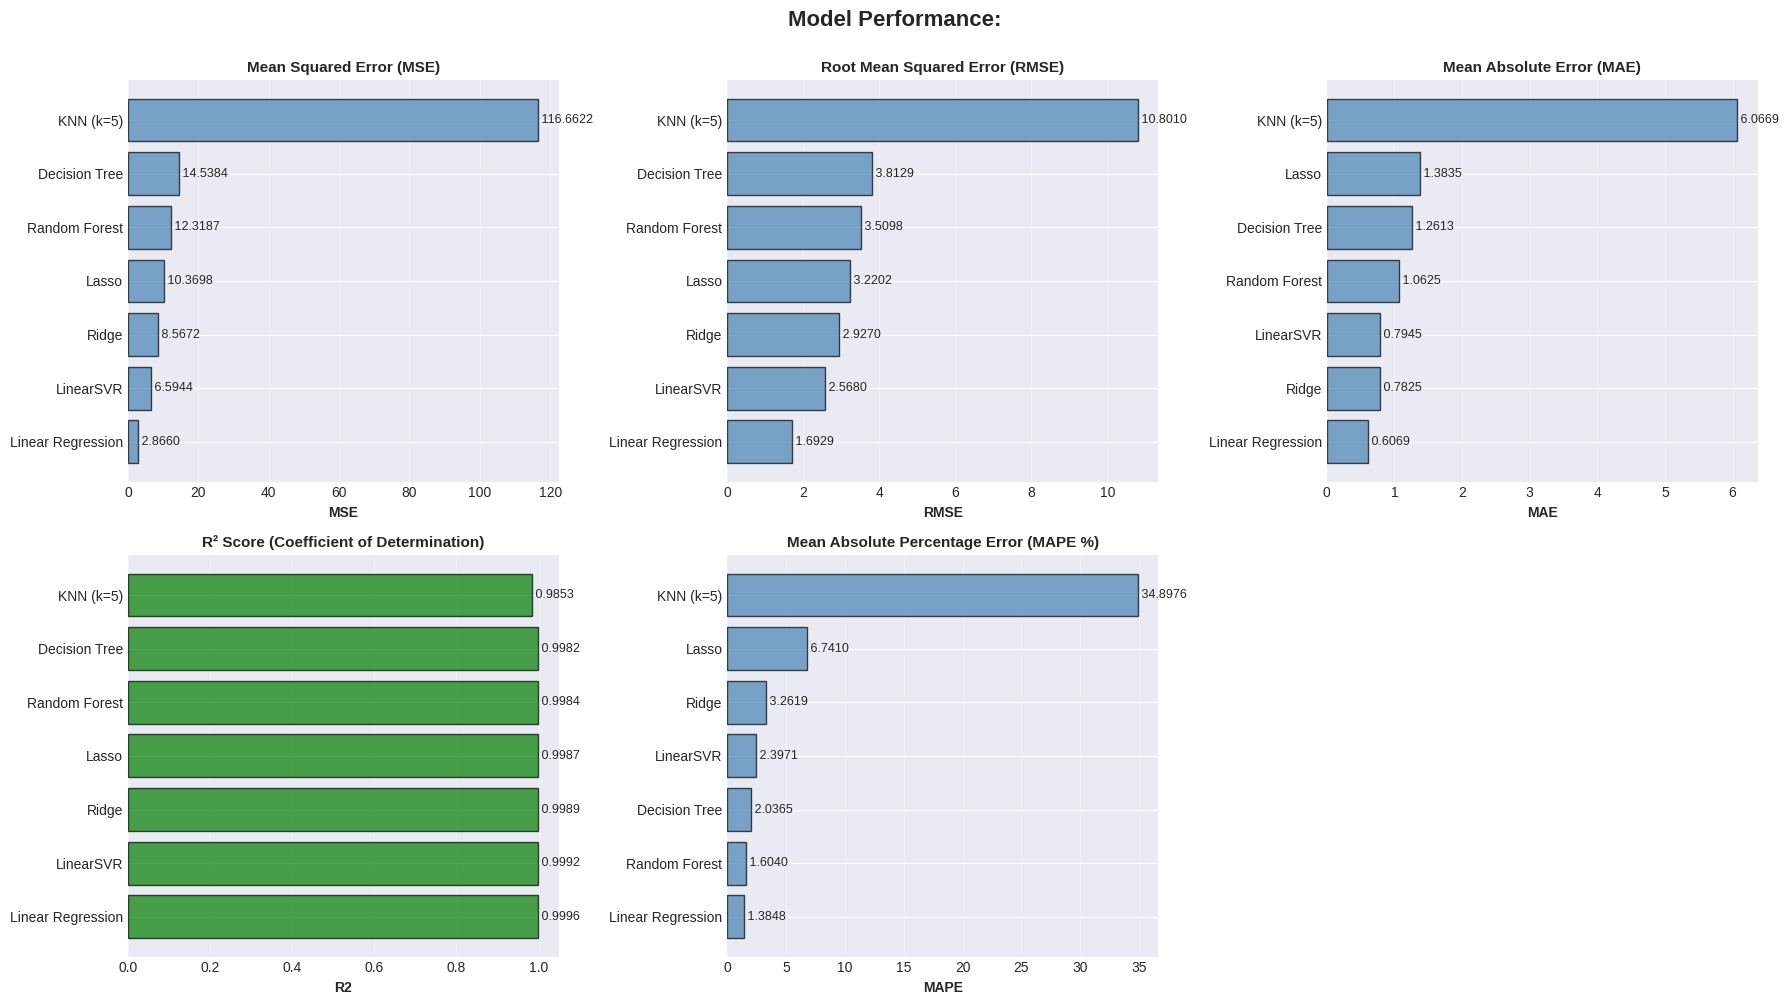

In [16]:
# bar charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance:', fontsize=16, fontweight='bold', y=1.00)

metrics = ['MSE', 'RMSE', 'MAE', 'R2', 'MAPE']
titles = ['Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 
          'Mean Absolute Error (MAE)', 'R² Score (Coefficient of Determination)', 
          'Mean Absolute Percentage Error (MAPE %)']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 3, idx % 3]

    # sort by metric value
    if metric == 'R2':
        sorted_df = results_df.sort_values(metric, ascending=False)
        colors = ['green' if x > 0 else 'red' for x in sorted_df[metric]]
    else:
        sorted_df = results_df.sort_values(metric, ascending=True)
        colors = ['steelblue'] * len(sorted_df)

    ax.barh(sorted_df.index, sorted_df[metric], color=colors, edgecolor='black', alpha=0.7)
    ax.set_xlabel(metric, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (model, value) in enumerate(zip(sorted_df.index, sorted_df[metric])):
        ax.text(value, i, f' {value:.4f}', va='center', fontsize=9)

# remove the 6th subplot (we only have 5 metrics)
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

8. Error Plots: 
============== 
> Predicted vs Actual  

This segment is meant to visualize prediction accuracy for the best models using dual error plots.


Error Plot: Linear Regression


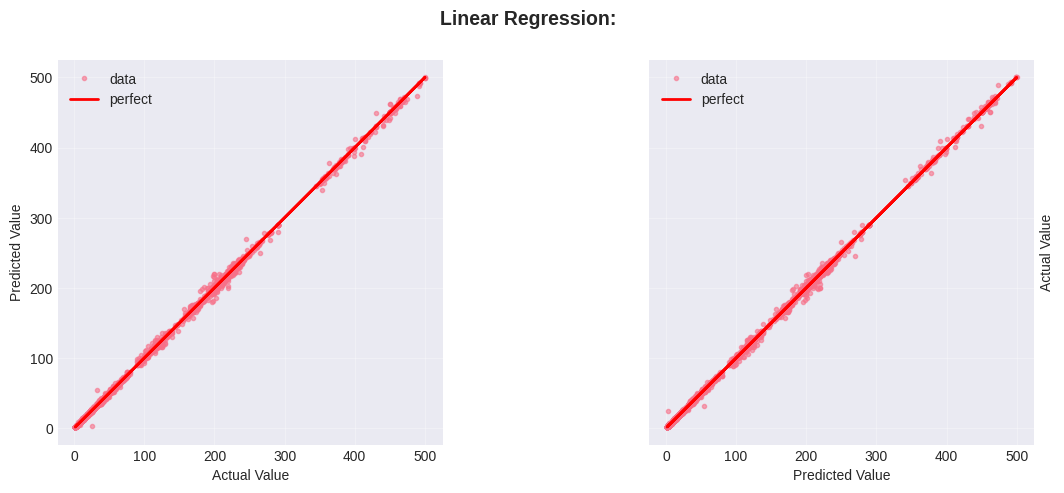


Error Plot: LinearSVR


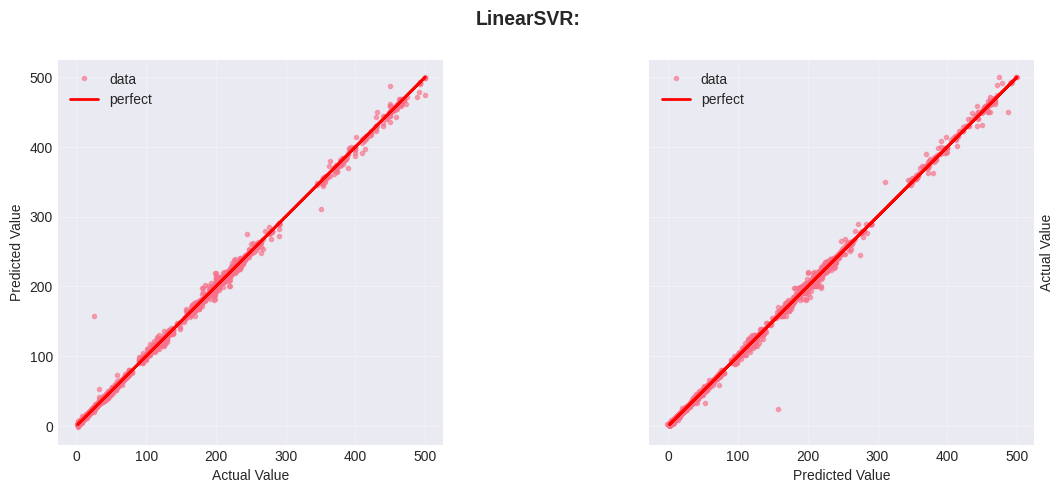


Error Plot: Ridge


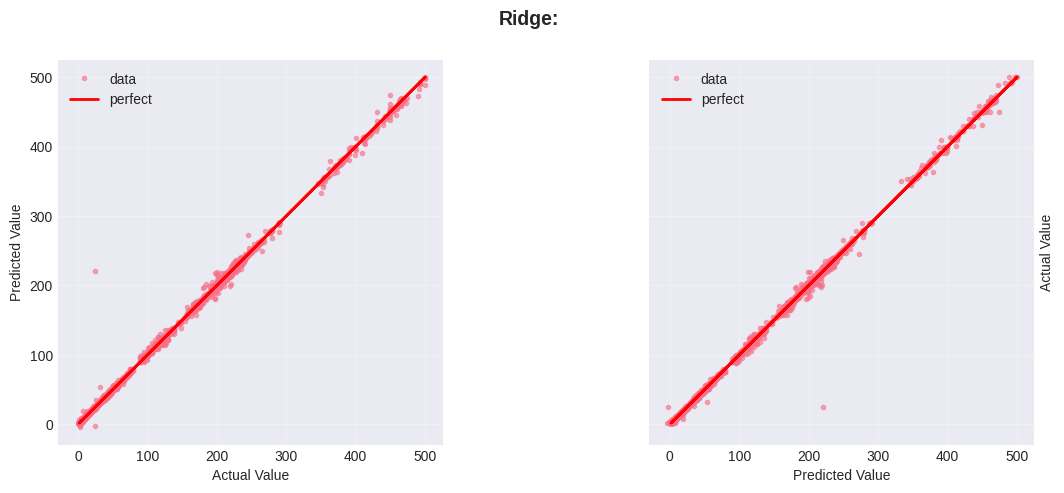

In [17]:
# top 3 models
top_3_models = results_df.head(3).index.tolist()

for model_name in top_3_models:
    print(f"\nError Plot: {model_name}")
    print("="*32)
    y_pred = predictions[model_name]
    fig, axes = regression_errors((14, 5), y_pred, y_test.values, errors=range(100))
    fig.suptitle(f'{model_name}:', fontsize=14, fontweight='bold')
    plt.show()

9. Residual Plots:
==================

This section examines residuals - `actual - predicted` - to identify systematic errors.

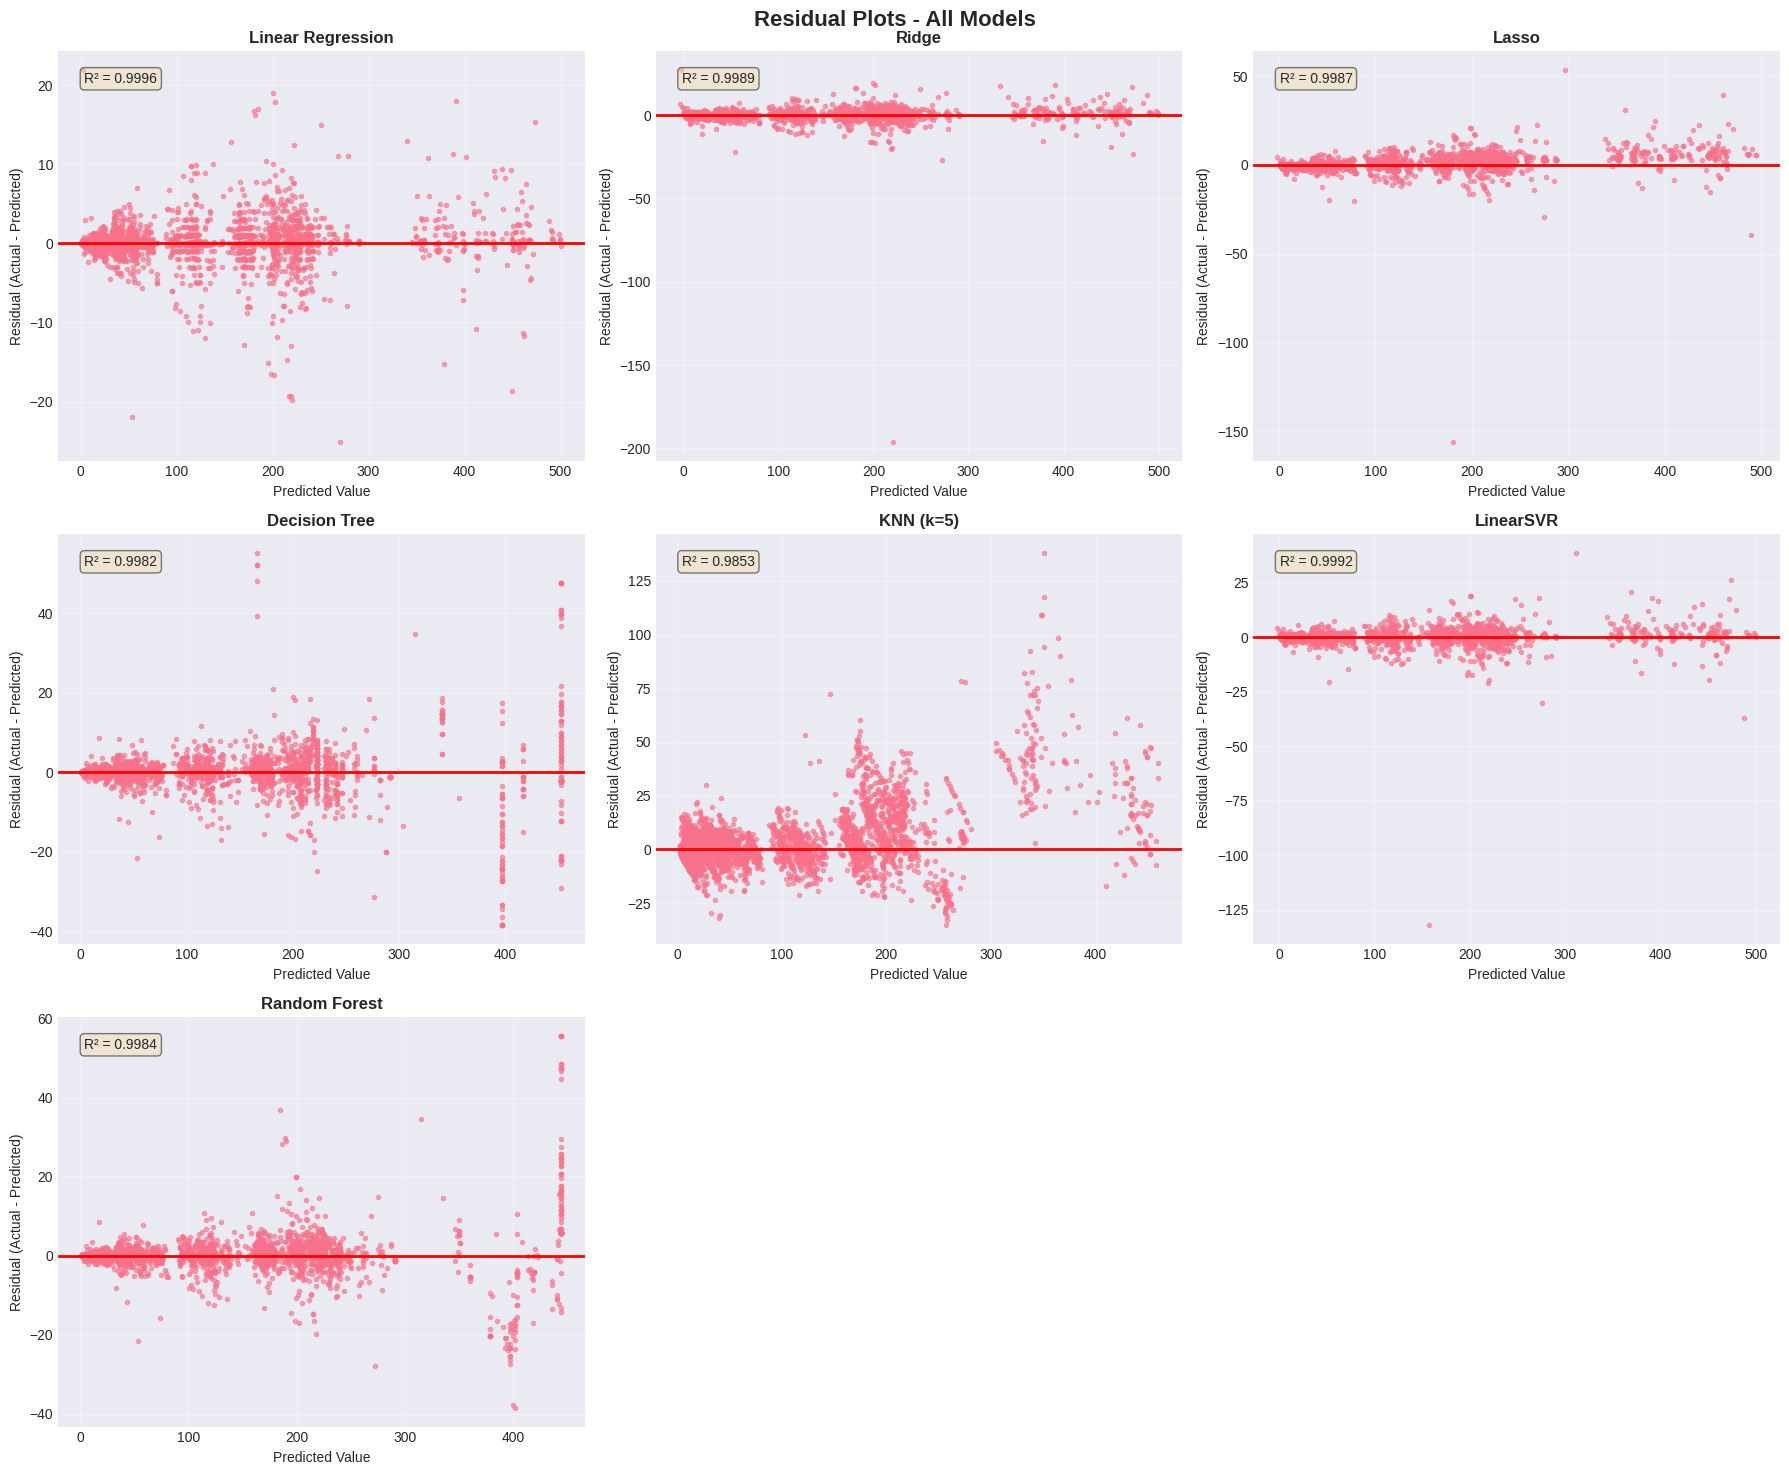

In [18]:
# residual plots for all models side-by-side
num_models = len(predictions)
ncols = 3
nrows = (num_models + ncols - 1) // ncols  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))
fig.suptitle('Residual Plots - All Models', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    regression_residuals(axes[idx], y_pred, y_test.values, show_errors=None)
    axes[idx].set_title(model_name, fontsize=12, fontweight='bold')

    # include R² score as part of plot
    r2 = results[model_name]['R2']
    axes[idx].text(0.05, 0.95, f'R² = {r2:.4f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# hide unused subplots
for idx in range(num_models, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

9b. Cross-Validation:
=====================
> #### `k-fold` cross-validation:
> Evaluate models using `5-fold` cross-validation to assess stability and generalization across different data splits.

In [19]:
# perform 5-fold cross-validation on all models
print("5-Fold Cross-Validation:")
print("="*70)

cv_results = {}
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# define scoring metrics
scoring = {
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'RMSE': make_scorer(neg_rmse_score, greater_is_better=False),
    'R2': 'r2'
}

for model_name, model in models.items():
    print(f"\n{model_name}...")
    cv_results[model_name] = {}
    
    # compute cross-validated scores for each metric
    for metric_name, scorer in scoring.items():
        if isinstance(scorer, str):
            scores = cross_val_score(model, X_train, y_train, cv=kf, scoring=scorer, n_jobs=-1)
        else:
            scores = cross_val_score(model, X_train, y_train, cv=kf, scoring=scorer, n_jobs=-1)
            scores = -scores  # negate to get positive values
        
        cv_results[model_name][metric_name] = scores
        mean_score = scores.mean()
        std_score = scores.std()
        print(f"  {metric_name}: {mean_score:.4f} (\u00b1 {std_score:.4f})")

5-Fold Cross-Validation:

Linear Regression...
  MAE: 0.7792 (± 0.0141)
  RMSE: -2.2725 (± 0.4672)
  R2: 0.9990 (± 0.0004)

Ridge...
  MAE: 0.9274 (± 0.0144)
  RMSE: -2.3959 (± 0.4247)
  R2: 0.9989 (± 0.0004)

Lasso...
  MAE: 1.4273 (± 0.0270)
  RMSE: -3.1398 (± 0.3748)
  R2: 0.9981 (± 0.0004)

Decision Tree...
  MAE: 1.1682 (± 0.0100)
  RMSE: -3.1144 (± 0.2752)
  R2: 0.9982 (± 0.0003)

KNN (k=5)...
  MAE: 4.0901 (± 0.0512)
  RMSE: -6.1393 (± 0.1884)
  R2: 0.9929 (± 0.0003)

LinearSVR...
  MAE: 0.9761 (± 0.0205)
  RMSE: -2.7316 (± 0.3796)
  R2: 0.9986 (± 0.0004)

Random Forest...
  MAE: 0.9726 (± 0.0121)
  RMSE: -2.7827 (± 0.3025)
  R2: 0.9985 (± 0.0003)


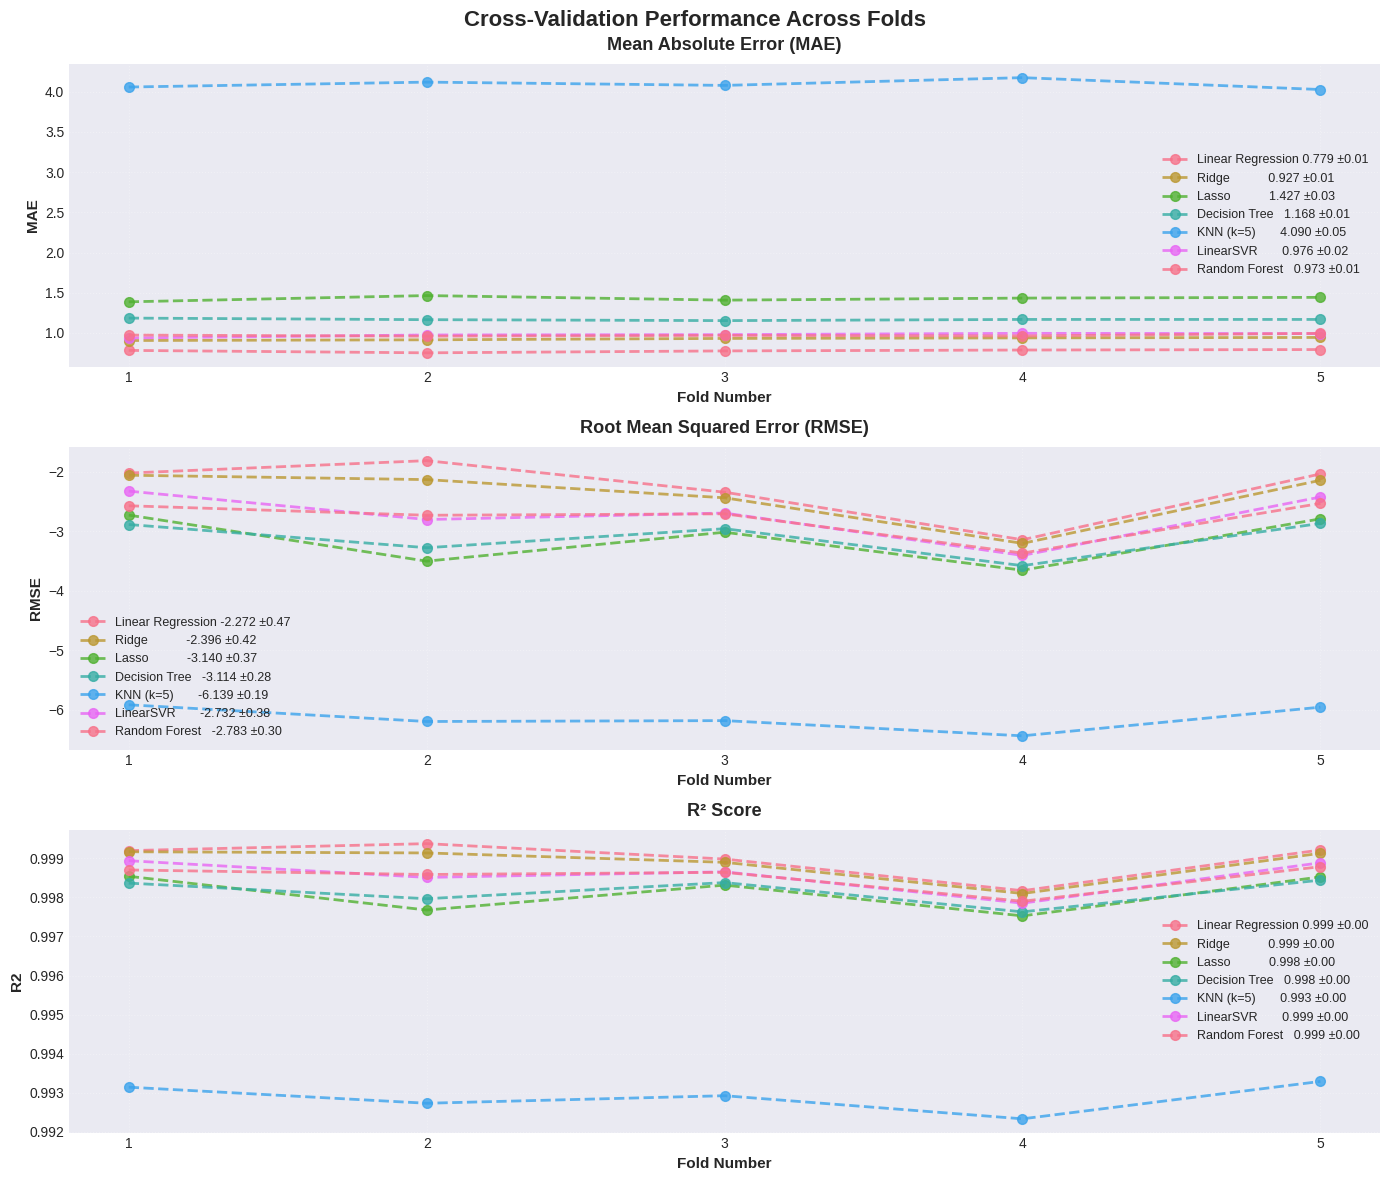

In [20]:
# visualize cross-validation results
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Cross-Validation Performance Across Folds', fontsize=16, fontweight='bold')

# prepare data for plotting
model_names = list(cv_results.keys())
metrics = ['MAE', 'RMSE', 'R2']
metric_labels = ['Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)', 'R² Score']

# plot each metric
for ax, metric, label in zip(axes, metrics, metric_labels):
    for model_name in model_names:
        metric_scores = cv_results[model_name][metric]
        mean_score = metric_scores.mean()
        std_score = metric_scores.std()
        
        # format label with model name, mean, and std
        my_label = "{:15s} {:.3f} ±{:.2f}".format(model_name, mean_score, std_score)
        
        # plot
        ax.plot(metric_scores, 'o--', label=my_label, linewidth=2, markersize=7, alpha=0.8)
    
    ax.set_title(label, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Fold Number', fontweight='bold', fontsize=11)
    ax.set_ylabel(metric, fontweight='bold', fontsize=11)
    ax.legend(loc='best', framealpha=0.95, fontsize=9, ncol=1)
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.set_xticks(range(len(metric_scores)))
    ax.set_xticklabels(range(1, len(metric_scores) + 1))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
# summary statistics table for cross-validation
cv_summary = {}
for model_name in model_names:
    cv_summary[model_name] = {
        'MAE_mean': cv_results[model_name]['MAE'].mean(),
        'MAE_std': cv_results[model_name]['MAE'].std(),
        'RMSE_mean': cv_results[model_name]['RMSE'].mean(),
        'RMSE_std': cv_results[model_name]['RMSE'].std(),
        'R2_mean': cv_results[model_name]['R2'].mean(),
        'R2_std': cv_results[model_name]['R2'].std()
    }

cv_summary_df = pd.DataFrame(cv_summary).T
cv_summary_df = cv_summary_df.sort_values('R2_mean', ascending=False)

print("\nCV Summary Statistics:")
print("="*90)
print(cv_summary_df.round(4))
print("\nInterpretation:")
print("  - Mean: Average performance across all folds")
print("  - Std: Standard deviation (lower = more stable/consistent)")
print(f"\nMost stable model (lowest R² std): {cv_summary_df['R2_std'].idxmin()}")
print(f"Best average performance (highest R² mean): {cv_summary_df.index[0]}")


CV Summary Statistics:
                   MAE_mean  MAE_std  RMSE_mean  RMSE_std  R2_mean  R2_std
Linear Regression    0.7792   0.0141    -2.2725    0.4672   0.9990  0.0004
Ridge                0.9274   0.0144    -2.3959    0.4247   0.9989  0.0004
LinearSVR            0.9761   0.0205    -2.7316    0.3796   0.9986  0.0004
Random Forest        0.9726   0.0121    -2.7827    0.3025   0.9985  0.0003
Decision Tree        1.1682   0.0100    -3.1144    0.2752   0.9982  0.0003
Lasso                1.4273   0.0270    -3.1398    0.3748   0.9981  0.0004
KNN (k=5)            4.0901   0.0512    -6.1393    0.1884   0.9929  0.0003

Interpretation:
  - Mean: Average performance across all folds
  - Std: Standard deviation (lower = more stable/consistent)

Most stable model (lowest R² std): Decision Tree
Best average performance (highest R² mean): Linear Regression


10. Ensemble Model - Random Forest:
===================================

The goal is to train and ascertain whether or not a Random Forest as an ensemble method model has improved performance.

In [22]:
# pass in optimized hyperparameters
print("Random Forest Regressor:")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# evaluate
rf_results = {
    'MSE': mean_squared_error(y_test, y_pred_rf),
    'RMSE': rms_error(y_test, y_pred_rf),
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf),
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_rf) * 100
}

print("\nRandom Forest Performance:")
print("="*26)
for metric, value in rf_results.items():
    print(f"{metric:10s}: {value:.4f}")

print(f"\nRandom Forest trained with {rf_model.n_estimators} trees")

Random Forest Regressor:

Random Forest Performance:
MSE       : 8.9331
RMSE      : 2.9888
MAE       : 0.9634
R2        : 0.9989
MAPE      : 1.5737

Random Forest trained with 100 trees



Top 10 Most Important Features:
      Feature  Importance
         MA_3    0.964083
        Lag_1    0.013193
     Previous    0.012517
         MA_5    0.009309
   Momentum_1    0.000250
        MA_10    0.000157
   Momentum_3    0.000151
        Lag_3    0.000087
Volume_Change    0.000062
        Lag_2    0.000054


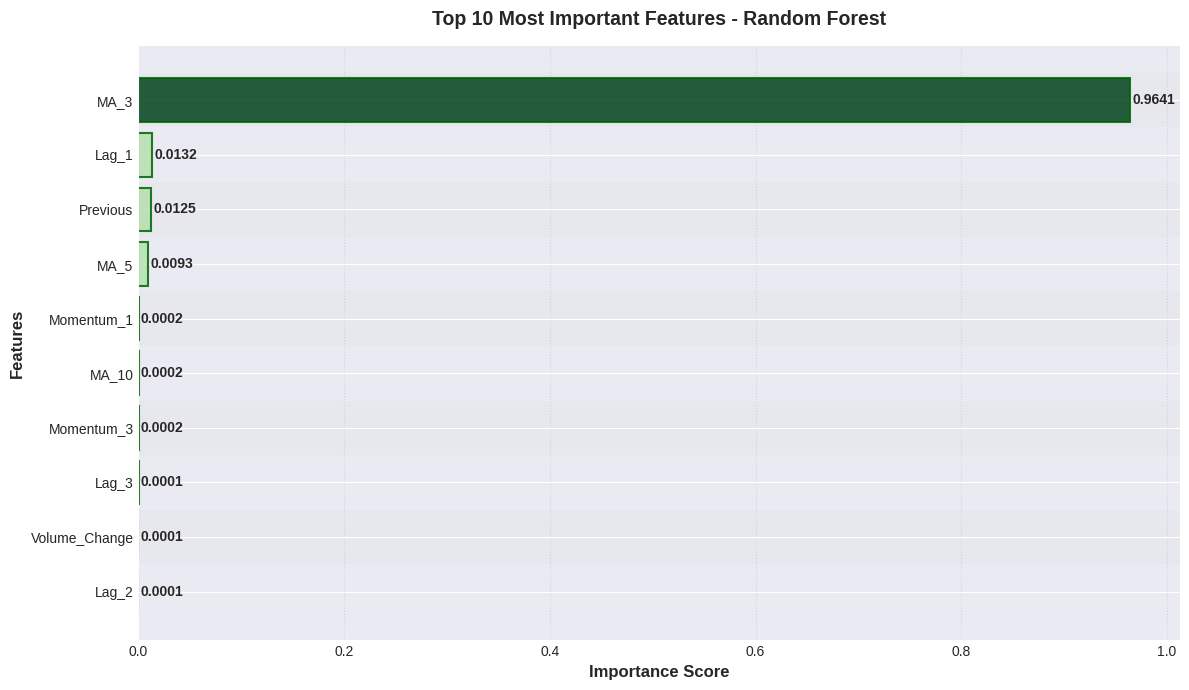

In [23]:
# feature importance from random forest
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print("="*70)
print(feature_importance.head(10).to_string(index=False))

# visualize feature importance
fig, ax = plt.subplots(figsize=(12, 7))
top_10 = feature_importance.head(10)

# create gradient colors from dark green (most important) to light green (least important)
importance_normalized = (top_10['Importance'] - top_10['Importance'].min()) / (top_10['Importance'].max() - top_10['Importance'].min())
colors = [plt.cm.Greens(0.3 + 0.7 * val) for val in importance_normalized]

# create horizontal bars
bars = ax.barh(top_10['Feature'], top_10['Importance'], color=colors, edgecolor='darkgreen', linewidth=1.5, alpha=0.85)

# styling
ax.set_xlabel('Importance Score', fontweight='bold', fontsize=12)
ax.set_ylabel('Features', fontweight='bold', fontsize=12)
ax.set_title('Top 10 Most Important Features - Random Forest', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.2, linestyle=':', color='gray')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# value labels formatted
for i, (feature, importance) in enumerate(zip(top_10['Feature'], top_10['Importance'])):
    ax.text(importance + 0.002, i, f'{importance:.4f}', va='center', fontsize=10, fontweight='bold')

# background shading
for i in range(len(top_10)):
    if i % 2 == 0:
        ax.axhspan(i - 0.5, i + 0.5, facecolor='lightgray', alpha=0.1, zorder=0)

plt.tight_layout()
plt.show()

11. Final Comparison: All Models + Random Forest
================================================

In [24]:
# add random forest to results
results['Random Forest'] = rf_results
predictions['Random Forest'] = y_pred_rf

# create final comparison dataframe
final_results = pd.DataFrame(results).T.sort_values('R2', ascending=False)

print("FINAL MODEL PERFORMANCE COMPARISON:")
print("="*90)
print(final_results.round(4))
print("\n" + "="*90)
print(f"Best Model: {final_results.index[0]}")
print(f"   R² Score: {final_results['R2'].iloc[0]:.4f}")
print(f"   RMSE: {final_results['RMSE'].iloc[0]:.4f}")
print(f"   MAE: {final_results['MAE'].iloc[0]:.4f}")
print(f"   MAPE: {final_results['MAPE'].iloc[0]:.2f}%")

FINAL MODEL PERFORMANCE COMPARISON:
                        MSE     RMSE     MAE      R2     MAPE
Linear Regression    2.8660   1.6929  0.6069  0.9996   1.3848
LinearSVR            6.5944   2.5680  0.7945  0.9992   2.3971
Ridge                8.5672   2.9270  0.7825  0.9989   3.2619
Random Forest        8.9331   2.9888  0.9634  0.9989   1.5737
Lasso               10.3698   3.2202  1.3835  0.9987   6.7410
Decision Tree       14.5384   3.8129  1.2613  0.9982   2.0365
KNN (k=5)          116.6622  10.8010  6.0669  0.9853  34.8976

Best Model: Linear Regression
   R² Score: 0.9996
   RMSE: 1.6929
   MAE: 0.6069
   MAPE: 1.38%


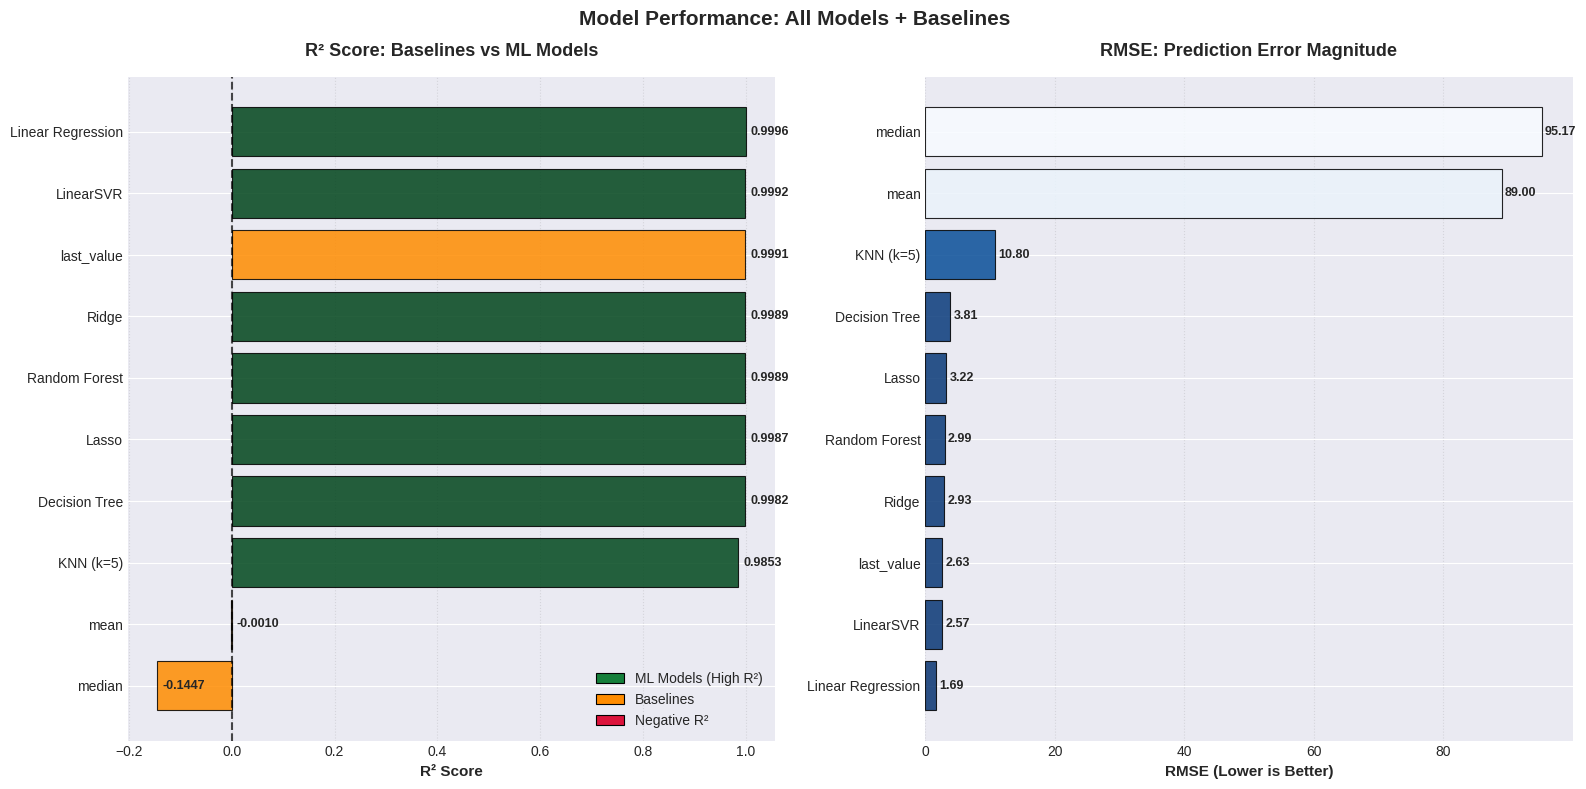

In [25]:
# visualization: comparing multiple metrics;
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# prep data
all_models = list(baseline_df.index) + list(final_results.index)
all_r2 = list(baseline_df['R2']) + list(final_results['R2'])
all_rmse = list(baseline_df['RMSE']) + list(final_results['RMSE'])

# LEFT PLOT: R² Score comparison
ax1 = axes[0]
colors_r2 = []
for model, r2 in zip(all_models, all_r2):
    if model in ['mean', 'median', 'last_value']:
        colors_r2.append('#FF8C00')  # dark orange for baselines
    elif r2 < 0:
        colors_r2.append('#DC143C')  # for negative
    else:
        intensity = min(1.0, max(0.3, r2))  # based on R² value
        colors_r2.append(plt.cm.Greens(intensity))

sorted_data = sorted(zip(all_models, all_r2, colors_r2), key=lambda x: x[1])
models_sorted, r2_sorted, colors_sorted = zip(*sorted_data)

ax1.barh(models_sorted, r2_sorted, color=colors_sorted, edgecolor='black', linewidth=0.8, alpha=0.85)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_xlabel('R² Score', fontweight='bold', fontsize=11)
ax1.set_title('R² Score: Baselines vs ML Models', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.2, linestyle=':', color='gray')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for i, (model, r2) in enumerate(zip(models_sorted, r2_sorted)):
    ax1.text(r2 + 0.01, i, f'{r2:.4f}', va='center', fontsize=9, fontweight='bold')

# legend for first plot
legend_elements = [
    Patch(facecolor=plt.cm.Greens(0.8), edgecolor='black', label='ML Models (High R²)', linewidth=0.8),
    Patch(facecolor='#FF8C00', edgecolor='black', label='Baselines', linewidth=0.8),
    Patch(facecolor='#DC143C', edgecolor='black', label='Negative R²', linewidth=0.8)
]
ax1.legend(handles=legend_elements, loc='lower right', framealpha=0.95, edgecolor='black')

# RIGHT PLOT: RMSE comparison
ax2 = axes[1]
sorted_rmse = sorted(zip(all_models, all_rmse), key=lambda x: x[1])
models_rmse, rmse_values = zip(*sorted_rmse)

# RMSE
rmse_colors = [plt.cm.Blues_r(min(1.0, rmse/max(rmse_values))) for rmse in rmse_values]

ax2.barh(models_rmse, rmse_values, color=rmse_colors, edgecolor='black', linewidth=0.8, alpha=0.85)
ax2.set_xlabel('RMSE (Lower is Better)', fontweight='bold', fontsize=11)
ax2.set_title('RMSE: Prediction Error Magnitude', fontsize=13, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.2, linestyle=':', color='gray')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for i, (model, rmse) in enumerate(zip(models_rmse, rmse_values)):
    ax2.text(rmse + 0.5, i, f'{rmse:.2f}', va='center', fontsize=9, fontweight='bold')

fig.suptitle('Model Performance: All Models + Baselines', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

12. WRAPS:
=========
> comments on the models and what was done

**1. Baseline:**
- **Last Value Baseline**: Predicting yesterday's price is a strong baseline for stock prices
- Stock prices are highly autocorrelated
- Any model must significantly outperform this simple baseline to be useful

**2. Linear Models:**
- Linear Regression, Ridge, and Lasso showed similar performance
- Regularization (Ridge/Lasso) didn't dramatically improve results
- Linear models struggle with non-linear stock price patterns

**3. Tree-Based Models:**
- Decision Tree and Random Forest captured non-linear relationships better
- Random Forest's ensemble approach reduced overfitting
- Lag prices (Lag_1, Lag_2) are most predictive

**4. Distance-Based Models:**
- KNN required careful scaling (StandardScaler in pipeline)
- Performance varied based on k value and distance metric
- Sensitive to irrelevant features

**5. Support Vector Regression:**
- SVR with RBF kernel showed good generalization
- Computationally expensive for large datasets
- StandardScaler essential for proper performance

------
```txt
SCT211-0848/2018
Jany Muong
```

#### END